# Quantivative Evaluation
This notebook documents the quantivative evalution of our game using for the **System Usability Scale (SUS)** and **NASA-TLX** for our game. <br>

## 1. Purpose 
The main purpose of this evaluation is to determine whether the two difficulty levels have a distinguishable difference in user experience and perceived workload. <br>

## 2. Data Collection

**Date**: 10 March 2026 <br> 
**Participants**: 10 <br>

Ten participants were asked to play two versions of the game: 
- a basic version: The spikes were pre-assigned and already placed for the players.

- a harder version: Players could place obstacles themselves and design their own map.

Each of them playered both versions and completed the SUS and NASA-TLX evalutations after playing the game.

## 3. Metrics
To evaluate the user experience, two established usability and workload metrics were used: **System Usability Scale** and **NASA Task Load Index**

### 3.1 NASA-TLX
It evaluates workload across six dimensions:
- Mental Demand  
- Physical Demand  
- Temporal Demand  
- Performance  
- Effort  
- Frustration  

Each dimension is rated on a scale from low to high workload.  

The ratings are then combined to produce an overall workload score. A higher NASA-TLX score indicates a higher perceived workload (i.e. the task felt more demanding for the participant).

### 3.2 SUS
SUS consists of 10 statements. The participants rate their agreement with each statement from 1 (strongly disagree) to 5 (strongly agree). 

1. I think that I would like to play this game frequently.  
2. I found the the game was unnecessarily complex.  
3. I thought the game was easy to play.  
4. I think that I would need the support of a technical person to be able to play this game.  
5. I found the various functions in this game were well integrated.  
6. I thought there was too much inconsistency in this game.  
7. I would imagine that most people would learn to use this game very quickly.  
8. I found the game very arkward to use.  
9. I felt very confident playing this game.  
10. I needed to learn a lot of things before I could know how to play this game.

## 4. Hypothesis
**Null Hypothesis**: There is no significant difference between the basic version and the harder version in terms of usability (SUS score) and percieved workload (NASA-TLX score)


## 5. Analysis 

### 5.1 NASA-TLX

In [275]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.patches as mpatches

In [276]:
# load data
data_nasa =  np.genfromtxt("NASA_TLX_evaluation.csv", delimiter=",")
data_sus =  np.genfromtxt("SUS_evaluation.csv", delimiter=",")

In [277]:
data_nasa_basic= data_nasa[2:8, 1:]
data_nasa_hard= data_nasa[12:, 1:]

data_sus_basic= data_sus[2:12, 1:]
data_sus_hard= data_sus[16:, 1:]

In [278]:
ave_data_nasa_basic = np.mean(data_nasa_basic, axis=1)
ave_data_nasa_hard = np.mean(data_nasa_hard, axis=1)

print("Average score for 6 dimensions (basic):", ave_data_nasa_basic)
print("Average score for 6 dimensions (hard):", ave_data_nasa_hard)


Average score for 6 dimensions (basic): [4.9 6.  6.8 5.  4.9 3. ]
Average score for 6 dimensions (hard): [14.5  9.6  8.4  5.6 13.5  9.9]


In [279]:
# Individual dimensions
workload = ["Mental", "Physical", "Temporal", "Performance", "Effort", "Frustration"]
for i in range(6):
    result = stats.wilcoxon(data_nasa_basic[i], data_nasa_hard[i])
    print(workload[i])
    print(f"Basic: {np.mean(data_nasa_basic[i]):.2f} +- {np.std(data_nasa_basic[i]):.2f} | "
      f"Hard: {np.mean(data_nasa_hard[i]):.2f} +- {np.std(data_nasa_hard[i]):.2f}")
    print(f"p-value: {result.pvalue:.4f}")
    print("")


Mental
Basic: 4.90 +- 3.67 | Hard: 14.50 +- 3.14
p-value: 0.0020

Physical
Basic: 6.00 +- 5.46 | Hard: 9.60 +- 4.54
p-value: 0.0781

Temporal
Basic: 6.80 +- 5.86 | Hard: 8.40 +- 5.70
p-value: 0.2188

Performance
Basic: 5.00 +- 6.26 | Hard: 5.60 +- 3.26
p-value: 0.8125

Effort
Basic: 4.90 +- 2.95 | Hard: 13.50 +- 3.26
p-value: 0.0039

Frustration
Basic: 3.00 +- 3.79 | Hard: 9.90 +- 6.82
p-value: 0.0469



In [280]:
# Average
result_final= stats.wilcoxon(ave_data_nasa_basic, ave_data_nasa_hard)
print("Average")
print(f"Basic: {np.mean(ave_data_nasa_basic):.2f} +- {np.std(ave_data_nasa_basic):.2f} | "
      f"Hard: {np.mean(ave_data_nasa_hard):.2f} +- {np.std(ave_data_nasa_hard):.2f}")
print(f"p-value: {result_final.pvalue:.4f}")

Average
Basic: 5.10 +- 1.17 | Hard: 10.25 +- 3.01
p-value: 0.0312


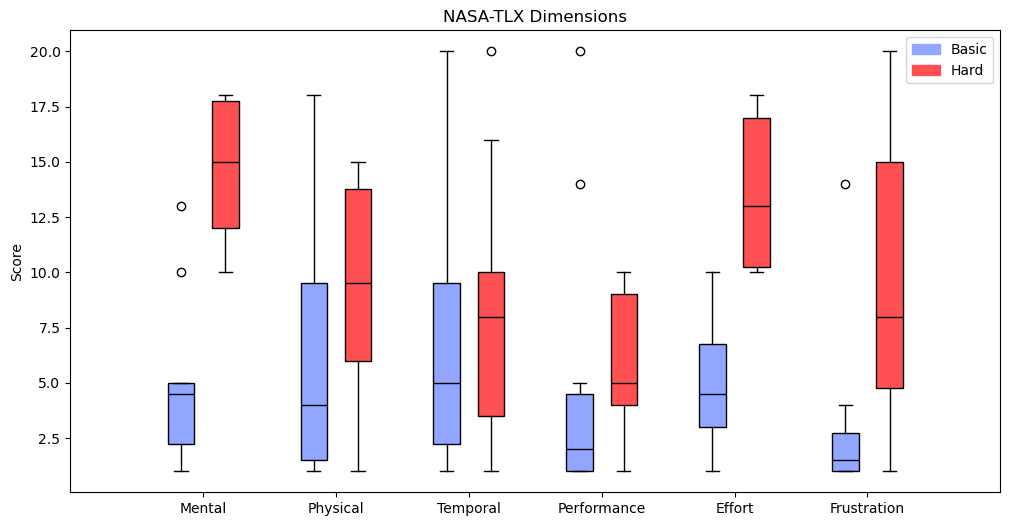

In [287]:
# box plot for NASA-TLX
plt.figure(figsize=(12,6))

pos=(0.5,0.7,1.1,1.3,1.7,1.9,2.3,2.5,2.9,3.1,3.5,3.7)

box = plt.boxplot([
    data_nasa_basic[0,:], data_nasa_hard[0,:],
    data_nasa_basic[1,:], data_nasa_hard[1,:],
    data_nasa_basic[2,:], data_nasa_hard[2,:],
    data_nasa_basic[3,:], data_nasa_hard[3,:],
    data_nasa_basic[4,:], data_nasa_hard[4,:],
    data_nasa_basic[5,:], data_nasa_hard[5,:], 
], positions=pos, 
widths=0.12, 
patch_artist=True,
medianprops=dict(color='black', linewidth=1))

basic_color = "#91A6FF"
hard_color = "#FF5154"

for i, patch in enumerate(box['boxes']):
    if i%2 == 0:
        patch.set_facecolor(basic_color)   
    else:
        patch.set_facecolor(hard_color)

plt.xticks(
    [0.6,1.2,1.8,2.4,3.0,3.6],
    ['Mental','Physical','Temporal','Performance','Effort','Frustration']
)
basic_patch = mpatches.Patch(color=basic_color, label='Basic')
hard_patch = mpatches.Patch(color=hard_color, label='Hard')
plt.legend(handles=[basic_patch, hard_patch])
plt.ylabel("Score")
plt.title("NASA-TLX Dimensions")
plt.show()

/var/folders/7p/ktlwj9pn5599m74w9l9r5nq00000gn/T/ipykernel_9614/2099993843.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot([ave_data_nasa_basic, ave_data_nasa_hard],


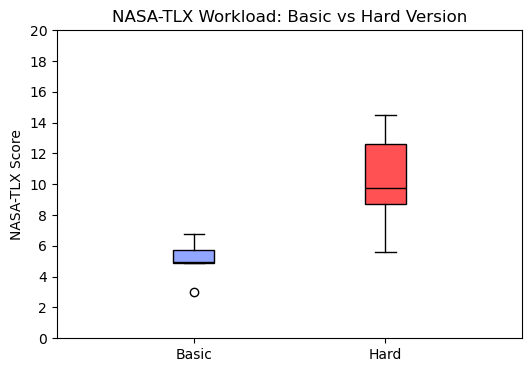

In [303]:
# NASA-TLX score 
plt.figure(figsize=(6,4))
pos=(0.5,1.2)

box = plt.boxplot([ave_data_nasa_basic, ave_data_nasa_hard],
            labels=['Basic','Hard'], 
            patch_artist=True,
            positions=pos,
            medianprops=dict(color='black', linewidth=1))

colors = ["#91A6FF", "#FF5154"]  # Basic, Hard

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.ylabel("NASA-TLX Score")
plt.title("NASA-TLX Workload: Basic vs Hard Version")
plt.ylim(0,20)
plt.yticks(range(0,21,2))
plt.show()

### 5.2 SUS

In [283]:
# Individual statements
question = ["Q1", "Q2", "Q3", "Q4", "Q5", "Q6", "Q7", "Q8", "Q9", "Q10"]
for i in range(10):
    
    result_sus = stats.wilcoxon(data_sus_basic[i], data_sus_hard[i])
    print(f"{question[i]} -> "
          f"Basic: {np.mean(data_sus_basic[i]):.2f} +- {np.std(data_sus_basic[i]):.2f} | "
          f"Hard: {np.mean(data_sus_hard[i]):.2f} +- {np.std(data_sus_hard[i]):.2f} | "
          f"p = {result_sus.pvalue:.4f}")
    print("")

Q1 -> Basic: 2.60 +- 0.80 | Hard: 3.00 +- 1.18 | p = 0.5156

Q2 -> Basic: 1.80 +- 1.08 | Hard: 2.20 +- 1.33 | p = 0.5000

Q3 -> Basic: 3.20 +- 1.54 | Hard: 3.50 +- 0.92 | p = 0.5742

Q4 -> Basic: 1.50 +- 0.81 | Hard: 2.40 +- 1.56 | p = 0.1250

Q5 -> Basic: 3.20 +- 0.60 | Hard: 3.40 +- 1.62 | p = 0.7344

Q6 -> Basic: 1.90 +- 0.83 | Hard: 2.40 +- 1.43 | p = 0.2500

Q7 -> Basic: 3.80 +- 1.17 | Hard: 3.50 +- 1.36 | p = 0.5312

Q8 -> Basic: 2.00 +- 1.00 | Hard: 1.70 +- 0.90 | p = 0.5000

Q9 -> Basic: 4.00 +- 1.18 | Hard: 3.20 +- 0.98 | p = 0.1719

Q10 -> Basic: 1.30 +- 0.46 | Hard: 2.20 +- 1.17 | p = 0.0625



In [284]:
# Final Result 
# odd-numbered questions subtract 1 from the response
# even-numbered questions subtract the response from 5

data_sus_basic_copy = data_sus_basic.copy()
data_sus_hard_copy = data_sus_hard.copy()

for i in range(10):
    if i % 2 == 0:
        data_sus_basic_copy[i] = data_sus_basic[i]-1
        data_sus_hard_copy[i]= data_sus_hard[i]-1
    else:
        data_sus_basic_copy[i] = 5-data_sus_basic[i]
        data_sus_hard_copy[i] = 5-data_sus_hard[i]

# sum the adjusted scores and multiply by 2.5
adjusted_sus_basic = np.sum(data_sus_basic_copy, axis=0) 
adjusted_sus_hard = np.sum(data_sus_hard_copy, axis=0) 

final_ave_sus_basic = adjusted_sus_basic * 2.5
final_ave_sus_hard = adjusted_sus_hard * 2.5


In [ ]:
# SUS score
result_sus_final= stats.wilcoxon(final_ave_sus_basic, final_ave_sus_hard)
print("Average")
print(f"Basic: {np.mean(final_ave_sus_basic):.2f} +- {np.std(final_ave_sus_basic):.2f} | "
      f"Hard: {np.mean(final_ave_sus_hard):.2f} +- {np.std(final_ave_sus_hard):.2f}")
print(f"p-value: {result_sus_final.pvalue:.4f}")

Average
Basic: 70.75 +- 14.96 | Hard: 64.25 +- 19.46
p-value: 0.2812


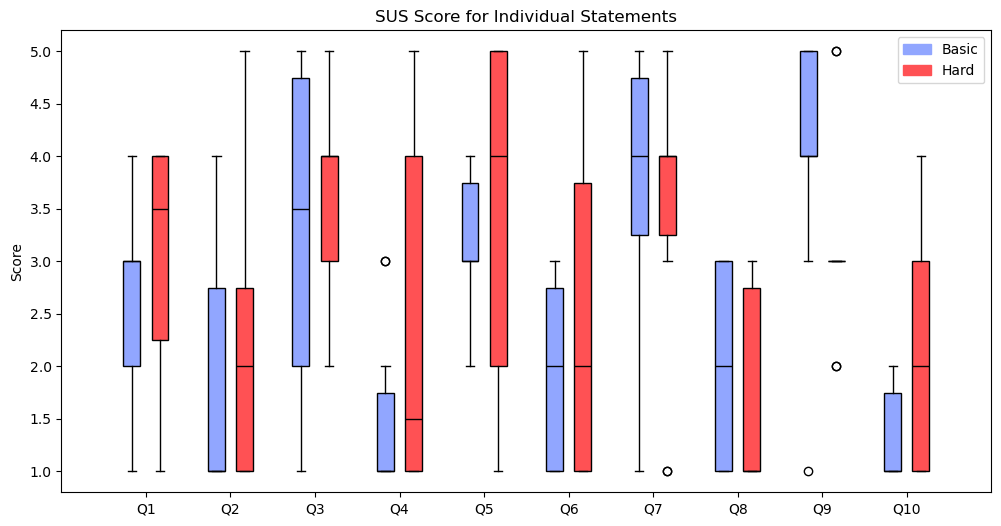

In [308]:
# box plot for SUS

plt.figure(figsize=(12,6))

pos = (0.5,0.7,1.1,1.3,1.7,1.9,2.3,2.5,2.9,3.1,
       3.5,3.7,4.1,4.3,4.7,4.9,5.3,5.5,5.9,6.1)

box = plt.boxplot([
    data_sus_basic[0,:], data_sus_hard[0,:],
    data_sus_basic[1,:], data_sus_hard[1,:],
    data_sus_basic[2,:], data_sus_hard[2,:],
    data_sus_basic[3,:], data_sus_hard[3,:],
    data_sus_basic[4,:], data_sus_hard[4,:],
    data_sus_basic[5,:], data_sus_hard[5,:],
    data_sus_basic[6,:], data_sus_hard[6,:],
    data_sus_basic[7,:], data_sus_hard[7,:],
    data_sus_basic[8,:], data_sus_hard[8,:],
    data_sus_basic[9,:], data_sus_hard[9,:] 
], positions=pos, 
widths=0.12, 
patch_artist=True,
medianprops=dict(color='black', linewidth=1))

basic_color = "#91A6FF"
hard_color = "#FF5154"

for i, patch in enumerate(box['boxes']):
    if i%2 == 0:
        patch.set_facecolor(basic_color)   
    else:
        patch.set_facecolor(hard_color)

plt.xticks(
    [0.6,1.2,1.8,2.4,3.0,3.6,4.2,4.8,5.4,6.0],
    ['Q1','Q2','Q3','Q4','Q5','Q6','Q7','Q8','Q9','Q10']
)
basic_patch = mpatches.Patch(color=basic_color, label='Basic')
hard_patch = mpatches.Patch(color=hard_color, label='Hard')
plt.legend(handles=[basic_patch, hard_patch])
plt.ylabel("Score")
plt.title("SUS Score for Individual Statements")

plt.show()


/var/folders/7p/ktlwj9pn5599m74w9l9r5nq00000gn/T/ipykernel_9614/462457029.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot([final_ave_sus_basic, final_ave_sus_hard],


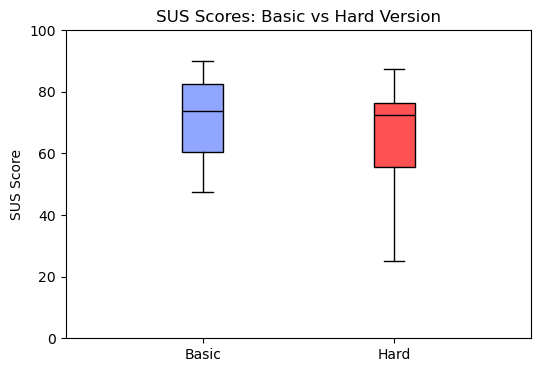

In [300]:
# SUS score 
plt.figure(figsize=(6,4))
pos=(0.5,1.2)

box = plt.boxplot([final_ave_sus_basic, final_ave_sus_hard],
            labels=['Basic','Hard'], 
            patch_artist=True,
            positions=pos,
            medianprops=dict(color='black', linewidth=1))

colors = ["#91A6FF", "#FF5154"]  # Basic, Hard

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.title("SUS Scores: Basic vs Hard Version")
plt.ylabel("SUS Score")
plt.ylim(0,100)
plt.show()

## 6. Conclusion 

Participants reported a significantly higher workload, measured by NASA-TLX, in the harder version compared to the basic version (p=0.032), driven primarily by increases in mental demand (p=0.002), effort (p=0.003) and frustration (p=0.046). However, usability ratings measured by SUS showed no significant differences between the two versions.

A SUS score of around 68 is considered average usability and scores above 80 are considered excellent. Our scores obtained for both versions (Basic: 70.75, Hard: 64.25) suggest the usability of our game at this stage is around the average usability level.